<h1> Configuration 

In [17]:
STEP          = "1"   # "1" or "2"

RESULTS_PATH  = f"/mnt/data/zaid/projects/results/step_{STEP}/results.csv"
HISTORY_PATH  = f"/mnt/data/zaid/projects/results/step_{STEP}/full_history.csv"

TOP_N         = 10       # number of top configs for individual plots
RANK_INTERVAL = (0, 5)  # (start, end) ranks shown on all-in-one plot, end is exclusive

SAVE_PLOTS    = False
PLOTS_DIR     = f"/mnt/data/zaid/projects/results/step_{STEP}/plots"


<h2> Imports, loading and preprocessing

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

if SAVE_PLOTS:
    os.makedirs(PLOTS_DIR, exist_ok=True)

results_df = pd.read_csv(RESULTS_PATH)
full_df    = pd.read_csv(HISTORY_PATH)

# --- Rank trials by best_val_loss ---
results_df = results_df.sort_values("best_val_loss", ascending=True).reset_index(drop=True)
results_df["rank"] = results_df.index + 1  # 1-indexed

# --- Auto-detect searched hyperparameters ---
config_cols   = [c for c in results_df.columns if c.startswith("config/")]
searched_cols = [c for c in config_cols if results_df[c].nunique() > 1]
param_names   = [c.replace("config/", "") for c in searched_cols]

print(f"Step:            {STEP}")
print(f"Total trials:    {len(results_df)}")
print(f"Searched params: {param_names}")


Step:            1
Total trials:    80
Searched params: ['lr', 'mpnn_hidden_dim', 'mpnn_num_layers', 'attn_num_heads', 'attn_num_layers', 'token_dim', 'pooling_strategy']


<h2> Summary Table

In [23]:
display_cols = ["rank", "best_val_loss", "best_val_loss_loc", "best_val_loss_str", 
                "best_epoch"] + searched_cols

top_n = trial_summary[display_cols].head(TOP_N).copy()
top_n.columns = ["rank", "best_val_loss", "loc_loss", "str_loss", 
                 "best_epoch"] + param_names

top_n.style \
     .highlight_min(subset=["best_val_loss"], color="lightgreen") \
     .format({"best_val_loss": "{:.6f}", "loc_loss": "{:.6f}", "str_loss": "{:.6f}"})


,rank,best_val_loss,loc_loss,str_loss,best_epoch,lr,mpnn_hidden_dim,mpnn_num_layers,attn_num_heads,attn_num_layers,token_dim,pooling_strategy
0,0,0.008326,0.006608,0.001718,116,0.000989,64,4,8,6,64,mean_pooling
1,1,0.008418,0.006489,0.001929,96,0.001347,64,4,8,6,64,mean_pooling
2,2,0.008557,0.006690,0.001866,105,0.001125,64,4,8,6,64,mean_pooling
3,3,0.008591,0.006720,0.001871,105,0.001290,64,4,8,6,128,mean_pooling
4,4,0.008619,0.006789,0.001831,109,0.000986,64,4,8,6,64,mean_pooling
5,5,0.008666,0.006882,0.001783,114,0.000202,256,4,4,4,128,mean_pooling
6,6,0.008678,0.006769,0.001909,108,0.000226,256,4,4,2,128,cls_token
7,7,0.008729,0.006937,0.001792,108,0.000537,64,3,4,2,64,mean_pooling
8,8,0.008743,0.006829,0.001914,107,0.000902,64,4,2,6,64,cls_token
9,9,0.008861,0.006843,0.002018,85,0.000488,128,4,8,6,64,mean_pooling


<h2> Overview Plot

/tmp/ipykernel_2954084/712006104.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("plasma_r", len(trials_in_range))


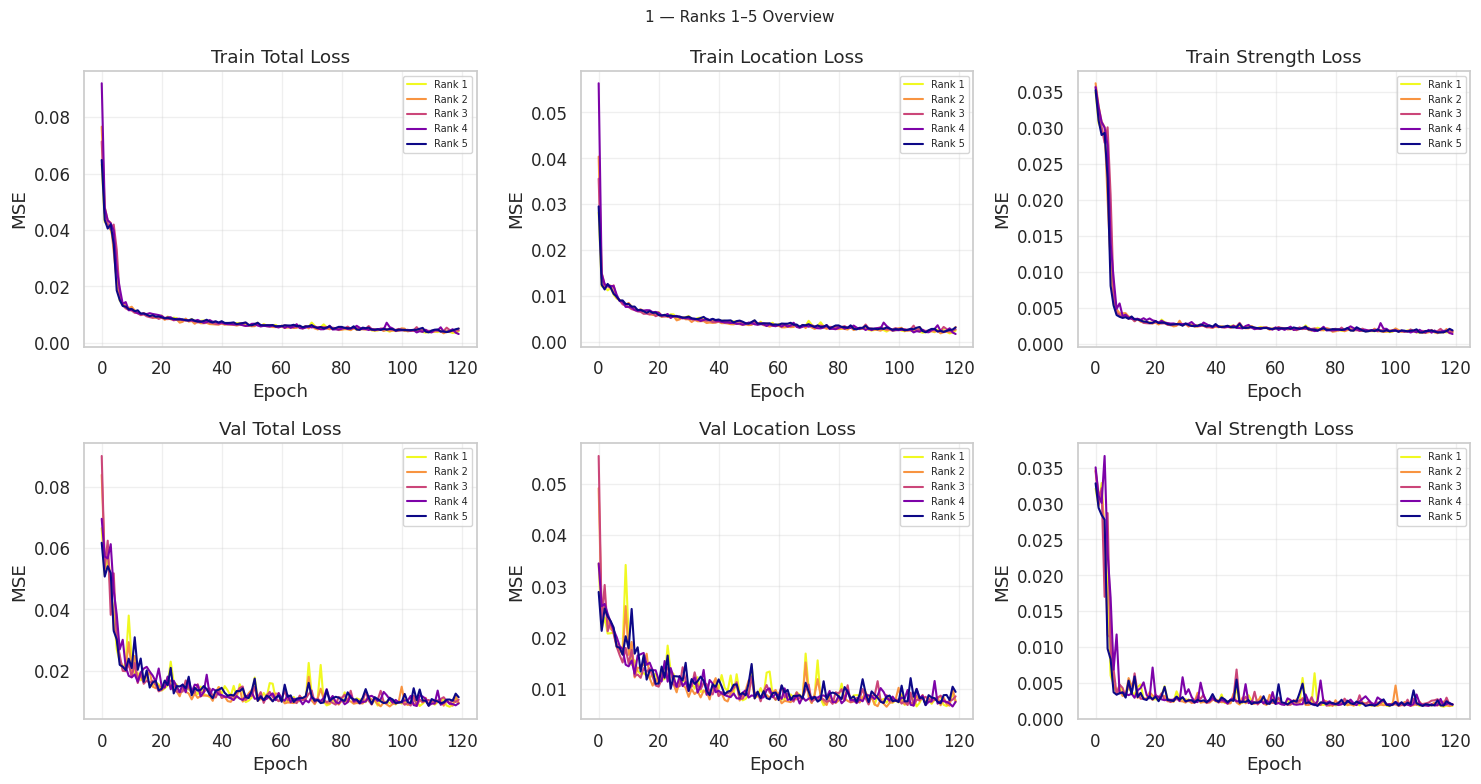

In [24]:
rank_start, rank_end = RANK_INTERVAL
trials_in_range = results_df[
    results_df["rank"].between(rank_start + 1, rank_end)
]

cmap   = cm.get_cmap("plasma_r", len(trials_in_range))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"{STEP} — Ranks {rank_start + 1}–{rank_end} Overview", fontsize=11)

for i, (_, row) in enumerate(trials_in_range.iterrows()):
    trial_df = full_df[full_df["trial_id"] == row["trial_id"]].sort_values("epoch")
    if trial_df.empty:
        continue

    epochs = trial_df["epoch"].values
    color  = cmap(i)
    label  = f"Rank {int(row['rank'])}"

    axes[0, 0].plot(epochs, trial_df["train_loss"].values,     color=color, label=label)
    axes[0, 1].plot(epochs, trial_df["train_loss_loc"].values, color=color, label=label)
    axes[0, 2].plot(epochs, trial_df["train_loss_str"].values, color=color, label=label)
    axes[1, 0].plot(epochs, trial_df["val_loss"].values,       color=color, label=label)
    axes[1, 1].plot(epochs, trial_df["val_loss_loc"].values,   color=color, label=label)
    axes[1, 2].plot(epochs, trial_df["val_loss_str"].values,   color=color, label=label)

axes[0, 0].set_title("Train Total Loss")
axes[0, 1].set_title("Train Location Loss")
axes[0, 2].set_title("Train Strength Loss")
axes[1, 0].set_title("Val Total Loss")
axes[1, 1].set_title("Val Location Loss")
axes[1, 2].set_title("Val Strength Loss")

for ax in axes.flat:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

plt.tight_layout()

if SAVE_PLOTS:
    plt.savefig(f"{PLOTS_DIR}/overview_ranks_{rank_start + 1}_{rank_end}.png",
                dpi=150, bbox_inches="tight")
plt.show()


<h2> Top Individual Plots

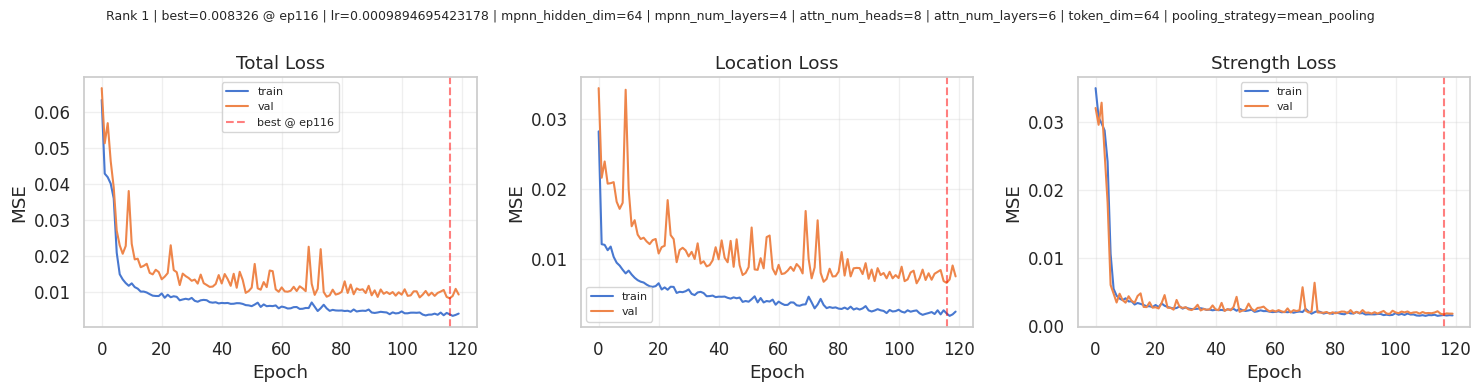

Rank  1 | best_val_loss: 0.008326 @ ep116 | epochs after best: 4 | lr=0.0009894695423178 | mpnn_hidden_dim=64 | mpnn_num_layers=4 | attn_num_heads=8 | attn_num_layers=6 | token_dim=64 | pooling_strategy=mean_pooling


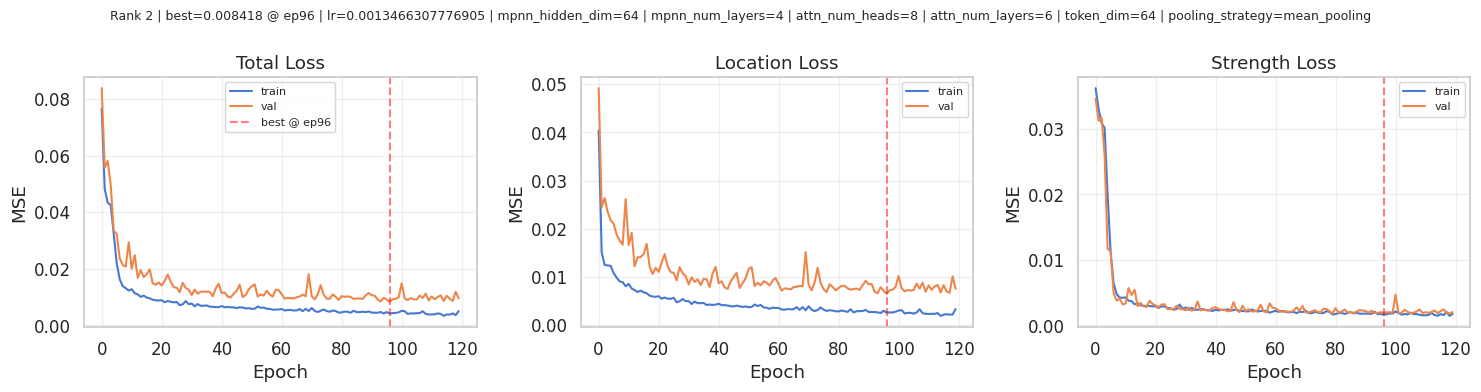

Rank  2 | best_val_loss: 0.008418 @ ep96 | epochs after best: 24 | lr=0.0013466307776905 | mpnn_hidden_dim=64 | mpnn_num_layers=4 | attn_num_heads=8 | attn_num_layers=6 | token_dim=64 | pooling_strategy=mean_pooling


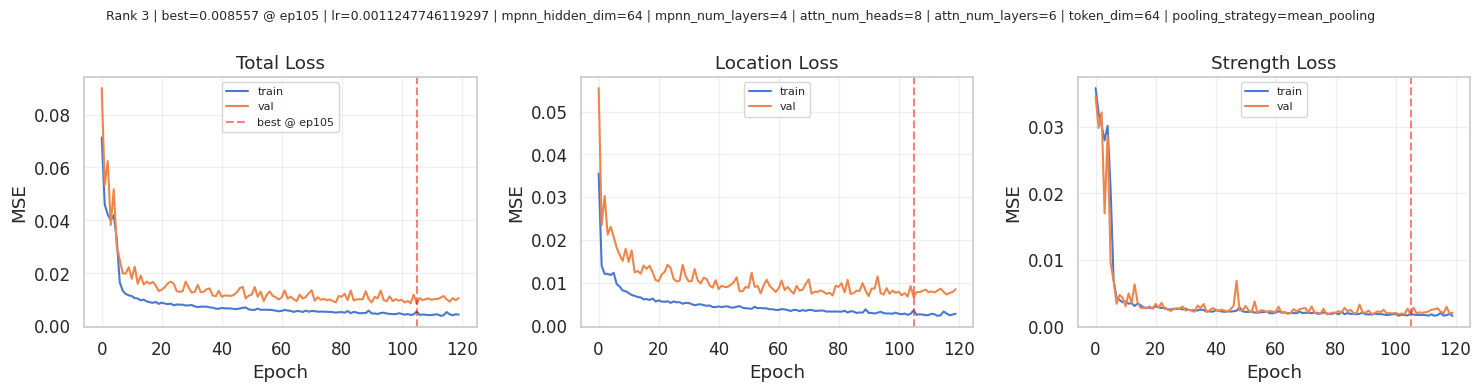

Rank  3 | best_val_loss: 0.008557 @ ep105 | epochs after best: 15 | lr=0.0011247746119297 | mpnn_hidden_dim=64 | mpnn_num_layers=4 | attn_num_heads=8 | attn_num_layers=6 | token_dim=64 | pooling_strategy=mean_pooling


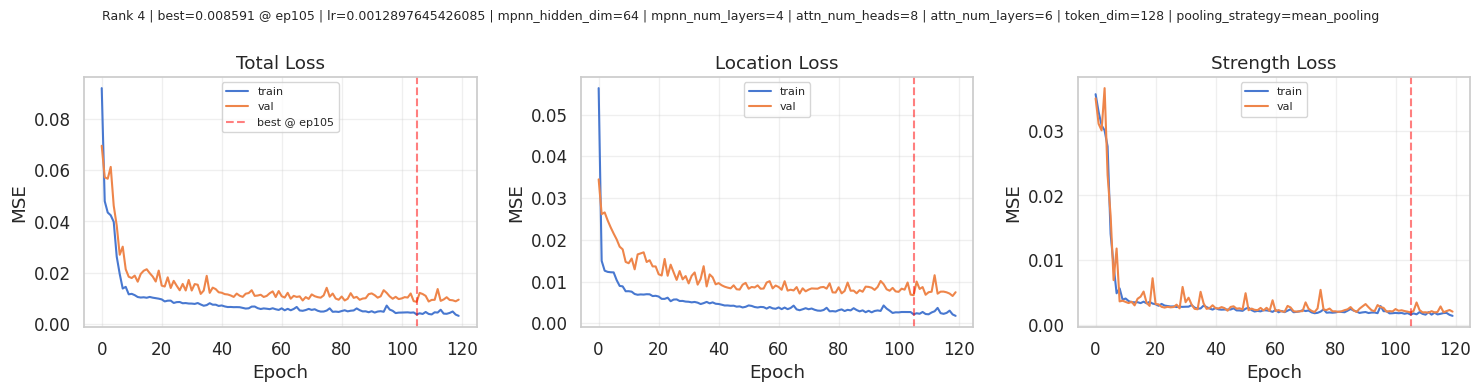

Rank  4 | best_val_loss: 0.008591 @ ep105 | epochs after best: 15 | lr=0.0012897645426085 | mpnn_hidden_dim=64 | mpnn_num_layers=4 | attn_num_heads=8 | attn_num_layers=6 | token_dim=128 | pooling_strategy=mean_pooling


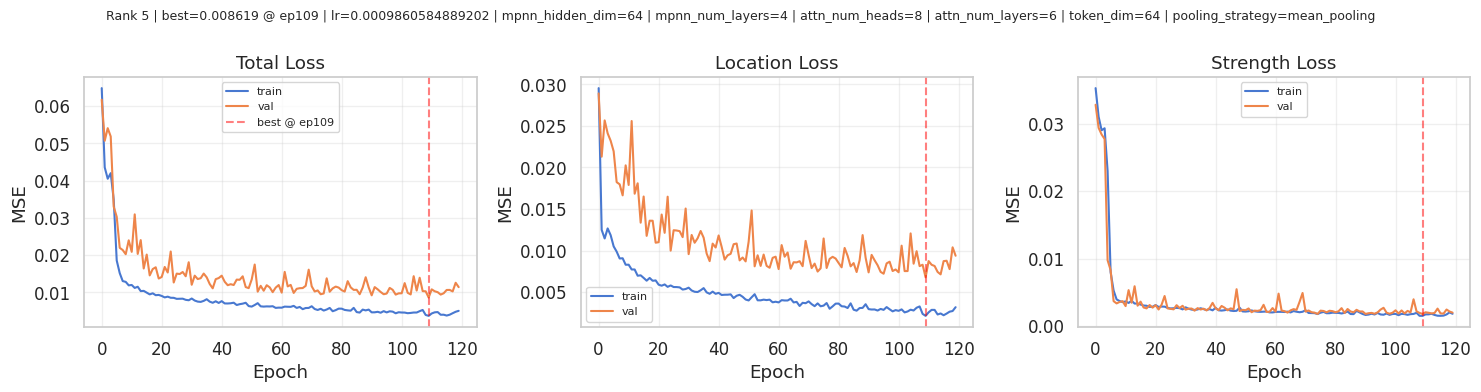

Rank  5 | best_val_loss: 0.008619 @ ep109 | epochs after best: 11 | lr=0.0009860584889202 | mpnn_hidden_dim=64 | mpnn_num_layers=4 | attn_num_heads=8 | attn_num_layers=6 | token_dim=64 | pooling_strategy=mean_pooling


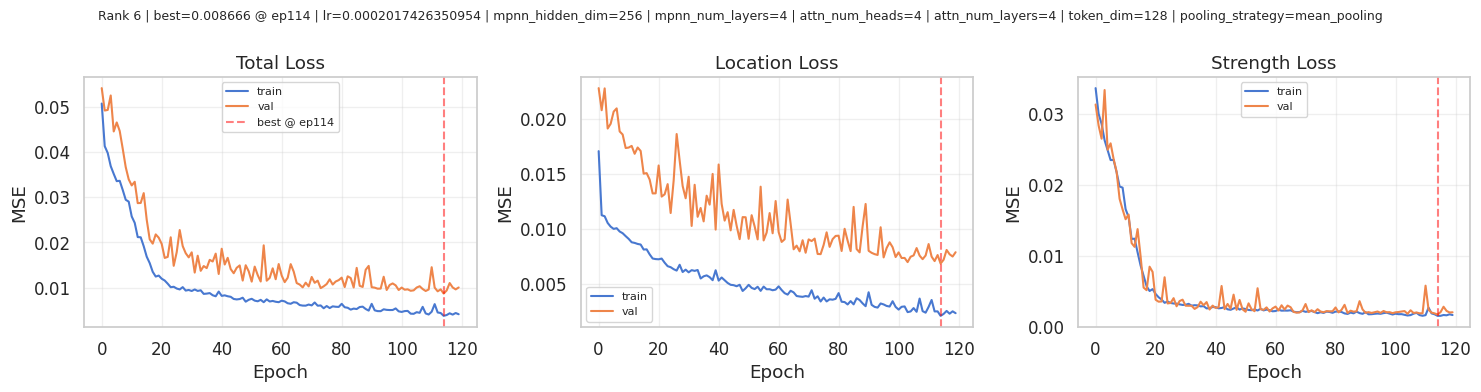

Rank  6 | best_val_loss: 0.008666 @ ep114 | epochs after best: 6 | lr=0.0002017426350954 | mpnn_hidden_dim=256 | mpnn_num_layers=4 | attn_num_heads=4 | attn_num_layers=4 | token_dim=128 | pooling_strategy=mean_pooling


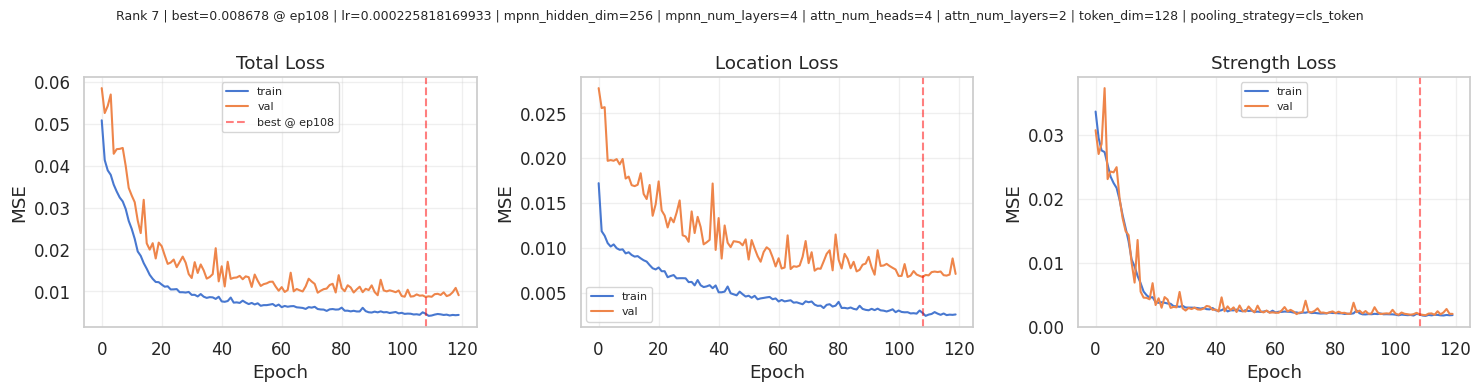

Rank  7 | best_val_loss: 0.008678 @ ep108 | epochs after best: 12 | lr=0.000225818169933 | mpnn_hidden_dim=256 | mpnn_num_layers=4 | attn_num_heads=4 | attn_num_layers=2 | token_dim=128 | pooling_strategy=cls_token


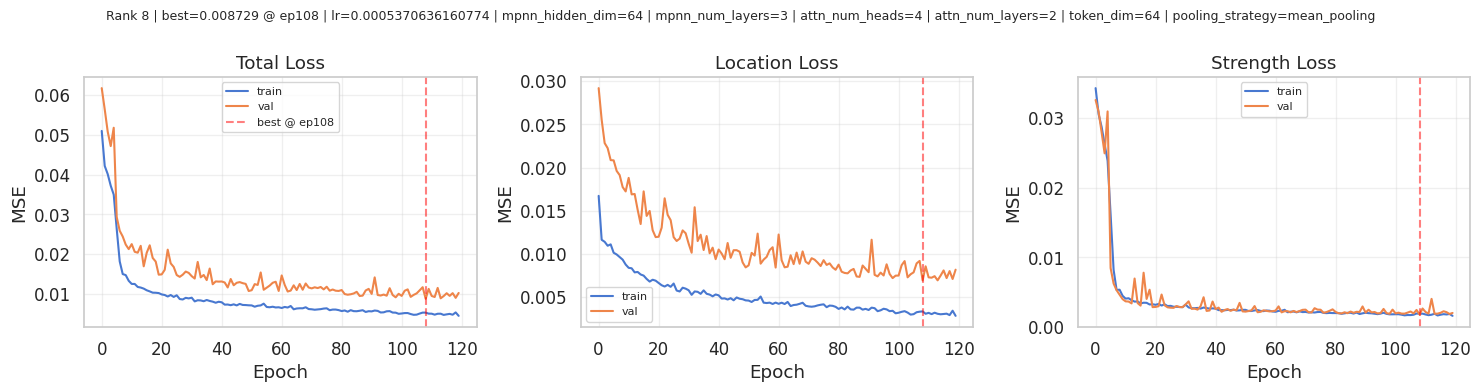

Rank  8 | best_val_loss: 0.008729 @ ep108 | epochs after best: 12 | lr=0.0005370636160774 | mpnn_hidden_dim=64 | mpnn_num_layers=3 | attn_num_heads=4 | attn_num_layers=2 | token_dim=64 | pooling_strategy=mean_pooling


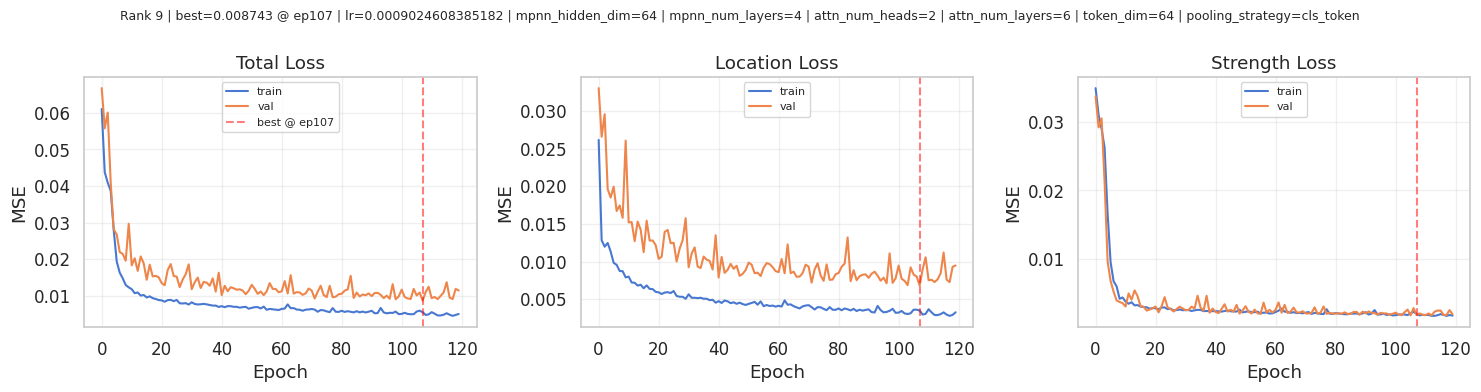

Rank  9 | best_val_loss: 0.008743 @ ep107 | epochs after best: 13 | lr=0.0009024608385182 | mpnn_hidden_dim=64 | mpnn_num_layers=4 | attn_num_heads=2 | attn_num_layers=6 | token_dim=64 | pooling_strategy=cls_token


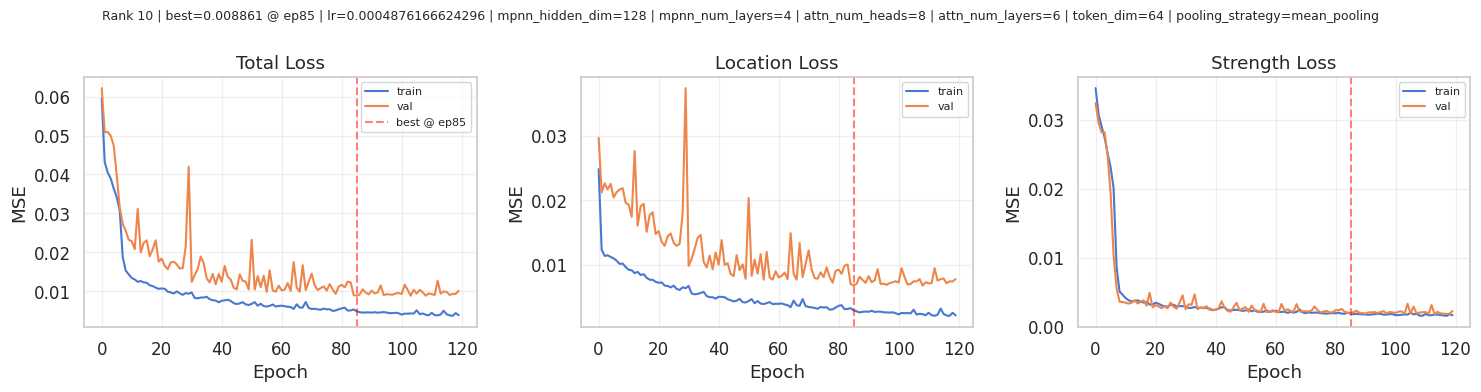

Rank 10 | best_val_loss: 0.008861 @ ep85 | epochs after best: 35 | lr=0.0004876166624296 | mpnn_hidden_dim=128 | mpnn_num_layers=4 | attn_num_heads=8 | attn_num_layers=6 | token_dim=64 | pooling_strategy=mean_pooling


In [25]:
for _, row in results_df.head(TOP_N).iterrows():
    rank     = int(row["rank"])
    trial_df = full_df[full_df["trial_id"] == row["trial_id"]].sort_values("epoch")

    if trial_df.empty:
        print(f"No history found for rank {rank}, skipping.")
        continue

    epochs        = trial_df["epoch"].values
    best_val_loss = trial_df["best_val_loss"].min()
    best_epoch    = trial_df.loc[trial_df["best_val_loss"].idxmin(), "epoch"]

    # --- Dynamic title from searched params ---
    param_str = " | ".join(
        f"{name}={row[f'config/{name}']}" for name in param_names
    )
    title = f"Rank {rank} | best={best_val_loss:.6f} @ ep{int(best_epoch)} | {param_str}"

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title, fontsize=9)

    axes[0].plot(epochs, trial_df["train_loss"].values,     label="train")
    axes[0].plot(epochs, trial_df["val_loss"].values,       label="val")
    axes[0].axvline(best_epoch, color="red", linestyle="--", alpha=0.5, label=f"best @ ep{int(best_epoch)}")
    axes[0].set_title("Total Loss")

    axes[1].plot(epochs, trial_df["train_loss_loc"].values, label="train")
    axes[1].plot(epochs, trial_df["val_loss_loc"].values,   label="val")
    axes[1].axvline(best_epoch, color="red", linestyle="--", alpha=0.5)
    axes[1].set_title("Location Loss")

    axes[2].plot(epochs, trial_df["train_loss_str"].values, label="train")
    axes[2].plot(epochs, trial_df["val_loss_str"].values,   label="val")
    axes[2].axvline(best_epoch, color="red", linestyle="--", alpha=0.5)
    axes[2].set_title("Strength Loss")

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig(f"{PLOTS_DIR}/rank_{rank:02d}.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(
        f"Rank {rank:2d} | best_val_loss: {best_val_loss:.6f} @ ep{int(best_epoch)} "
        f"| epochs after best: {int(len(epochs) - best_epoch)} | {param_str}"
    )

